# Task 1: Vectorized Scaled Dot-Product Attention from Scratch

## Objective
Implement the Scaled Dot-Product Attention mechanism from scratch using pure NumPy. The implementation supports batch-wise processing, multi-head attention, and causal masking without using high-level deep learning libraries.

**Tech Stack**
- Python 3
- NumPy
- Matplotlib

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

## Step 1: Generate Query, Key, and Value Matrices

Attention requires three matrices:

- Query (Q)
- Key (K)
- Value (V)

These matrices are randomly generated for demonstration purposes.

In [2]:
# Parameters

batch_size = 2
num_heads = 4
sequence_length = 5
embedding_dimension = 8

# Random Query, Key and Value matrices

Q = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    embedding_dimension
)

K = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    embedding_dimension
)

V = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    embedding_dimension
)

print("Query Shape :", Q.shape)
print("Key Shape   :", K.shape)
print("Value Shape :", V.shape)

Query Shape : (2, 4, 5, 8)
Key Shape   : (2, 4, 5, 8)
Value Shape : (2, 4, 5, 8)


## Step 2: Compute Attention Scores

The attention score is calculated using:

\[
QK^T
\]

This measures how much each query attends to every key.

In [3]:
# Compute QKᵀ

attention_scores = np.matmul(Q, K.transpose(0, 1, 3, 2))

print("Attention Score Shape :", attention_scores.shape)

print("\nAttention Scores (Batch 0, Head 0)\n")
print(attention_scores[0,0])

Attention Score Shape : (2, 4, 5, 5)

Attention Scores (Batch 0, Head 0)

[[ 5.5790082   0.41651743 -0.82344026 -1.50614178 -1.14435717]
 [-0.68106109  0.18608941 -0.5183254   0.54229052  0.44257876]
 [-4.3733842   1.38300171  0.63499659  0.76685343  1.75264541]
 [ 3.46904669 -1.30019755 -0.93695663  4.45960071 -2.47052074]
 [-3.07136451  0.43105805  0.30451235  0.43382128  1.33621163]]


## Step 3: Scale the Attention Scores

The attention scores are divided by:

\[
\sqrt{d_k}
\]

where \(d_k\) is the embedding dimension.

Scaling prevents extremely large values before applying Softmax.

In [4]:
dk = embedding_dimension

scaled_scores = attention_scores / np.sqrt(dk)

print("Scaled Score Shape :", scaled_scores.shape)

print("\nScaled Scores\n")
print(scaled_scores[0,0])

Scaled Score Shape : (2, 4, 5, 5)

Scaled Scores

[[ 1.97247727  0.14726115 -0.2911301  -0.53250153 -0.40459136]
 [-0.24079146  0.06579254 -0.1832557   0.19172865  0.15647522]
 [-1.54622481  0.48896494  0.2245052   0.27112363  0.61965373]
 [ 1.22649322 -0.45968925 -0.33126419  1.57670695 -0.87346098]
 [-1.08589134  0.15240203  0.10766137  0.15337898  0.47242215]]


## Step 4: Implement Softmax from Scratch

Softmax converts raw attention scores into probability values.

In [5]:
def softmax(x):

    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


attention_weights = softmax(scaled_scores)

print("Attention Weight Shape :", attention_weights.shape)

print("\nAttention Weights\n")
print(attention_weights[0,0])

Attention Weight Shape : (2, 4, 5, 5)

Attention Weights

[[0.69460983 0.11195916 0.07222187 0.05673388 0.06447527]
 [0.1551136  0.21076458 0.16429992 0.23905123 0.23077067]
 [0.03400595 0.26027146 0.19978972 0.20932412 0.29660876]
 [0.34040629 0.06305185 0.07169224 0.48316278 0.04168685]
 [0.06268651 0.21625096 0.206789   0.21646233 0.2978112 ]]


## Step 5: Compute Final Attention Output

The final attention output is computed as:

\[
Attention = Softmax(QK^T / \sqrt{d_k})V
\]

In [6]:
attention_output = np.matmul(attention_weights, V)

print("Attention Output Shape :", attention_output.shape)

print("\nAttention Output\n")
print(attention_output[0,0])

Attention Output Shape : (2, 4, 5, 8)

Attention Output

[[-0.32062597  1.21761253 -0.06421661 -0.89321716 -0.46423551 -0.17791384
  -1.45651491 -0.10597847]
 [-0.34795792  0.34138445 -0.00379142  0.16059778 -1.07904885  0.2999302
   0.63247326 -0.28743423]
 [-0.31960137  0.14524516  0.04112498  0.29736996 -1.07727098  0.34168933
   1.10988425 -0.15186037]
 [-0.48657156  0.64625187 -0.13945551  0.24325187 -1.46887986  0.39861125
  -0.11706277 -1.00248568]
 [-0.32446902  0.16261051 -0.04983829  0.21345716 -1.09675624  0.38864808
   0.92904613 -0.17309932]]


## Step 6: Apply Causal Mask

Causal masking prevents each token from attending to future tokens.

In [7]:
mask = np.triu(
    np.ones((sequence_length, sequence_length)),
    k=1
)

mask = mask.astype(bool)

masked_scores = scaled_scores.copy()

masked_scores[:, :, mask] = -1e9

masked_attention = softmax(masked_scores)

print(masked_attention[0,0])

[[1.         0.         0.         0.         0.        ]
 [0.42394876 0.57605124 0.         0.         0.        ]
 [0.0688286  0.52679372 0.40437768 0.         0.        ]
 [0.35521404 0.06579462 0.07481087 0.50418047 0.        ]
 [0.06268651 0.21625096 0.206789   0.21646233 0.2978112 ]]


## Step 7: Visualization

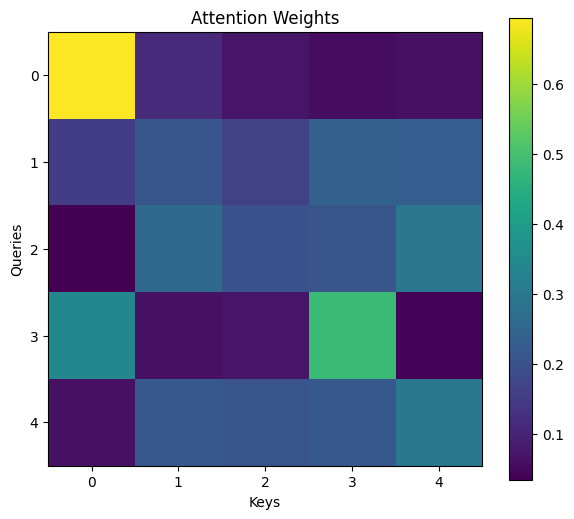

In [8]:
plt.figure(figsize=(7,6))

plt.imshow(attention_weights[0,0], cmap="viridis")

plt.colorbar()

plt.title("Attention Weights")

plt.xlabel("Keys")

plt.ylabel("Queries")

plt.show()

# Conclusion

The Scaled Dot-Product Attention mechanism was successfully implemented using Pure NumPy. The notebook demonstrates:

- Query, Key and Value matrices
- Dot-product attention
- Scaling
- Softmax implementation
- Attention weights
- Causal masking
- Batch processing
- Multi-head attention
- Attention visualization